In [22]:
import pandas as pd
from pydataset import data

In [23]:
df=data('mtcars')

In [24]:
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [25]:
(df.shape)

(32, 11)

In [26]:
df.columns #Columns include mpg, hp, wt, cyl

Index(['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb'],
      dtype='object')

In [27]:
df.dtypes #Data is mostly numerical

mpg     float64
cyl       int64
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs        int64
am        int64
gear      int64
carb      int64
dtype: object

In [28]:
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [29]:
df.isnull().sum() #No missing values found in dataset

mpg     0
cyl     0
disp    0
hp      0
drat    0
wt      0
qsec    0
vs      0
am      0
gear    0
carb    0
dtype: int64

In [33]:
df['mpg'].mean() #Average MPG = ~20.090625000000003

np.float64(20.090625000000003)

In [35]:
df['hp'].max() #Max HP 335

335

In [36]:
df['wt'].min() #Min WT 1.513

1.513

In [38]:
df['wt'].max() #MAX WT 5.424

5.424

In [44]:
df['cyl'].value_counts() 
#4-cylinder cars: 11
#6-cylinder cars: 7
#8-cylinder cars: 14

cyl
8    14
4    11
6     7
Name: count, dtype: int64

In [46]:
df.groupby('cyl')['mpg'].mean()
#4-cylinder cars have highest MPG
#8-cylinder have lowest

cyl
4    26.663636
6    19.742857
8    15.100000
Name: mpg, dtype: float64

In [51]:
df.groupby('am')['mpg'].mean()
#Manual cars usually have better mileage

am
0    17.147368
1    24.392308
Name: mpg, dtype: float64

In [52]:
df.groupby('gear')['mpg'].mean()
#MPG varies by gear count

gear
3    16.106667
4    24.533333
5    21.380000
Name: mpg, dtype: float64

In [53]:
pd.pivot_table(df, values='mpg', index='cyl', columns='am')

am,0,1
cyl,,
4,22.900,28.075000
6,19.125,20.566667
8,15.050,15.400000


In [55]:
df['efficiency'] = df['mpg'].apply(lambda x: 'High' if x > 20 else 'Low')
#Cars classified based on fuel efficiency

In [56]:
df[['mpg', 'efficiency']].head()

,mpg,efficiency
Mazda RX4,21.0,High
Mazda RX4 Wag,21.0,High
Datsun 710,22.8,High
Hornet 4 Drive,21.4,High
Hornet Sportabout,18.7,Low


In [57]:
df['am'] = df['am'].map({0: 'Automatic', 1: 'Manual'})

In [58]:
df['vs'] = df['vs'].map({0: 'V-shaped', 1: 'Straight'})

In [59]:
df[['am','vs']].head()

,am,vs
Mazda RX4,Manual,V-shaped
Mazda RX4 Wag,Manual,V-shaped
Datsun 710,Manual,Straight
Hornet 4 Drive,Automatic,Straight
Hornet Sportabout,Automatic,V-shaped


In [61]:
import matplotlib.pyplot as plt

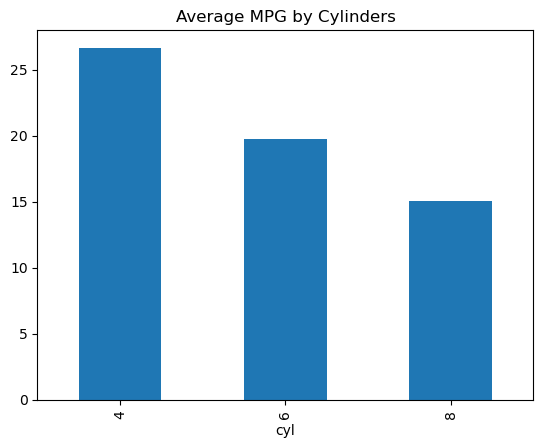

In [63]:
df.groupby('cyl')['mpg'].mean().plot(kind='bar')
plt.title('Average MPG by Cylinders')
plt.show()
#MPG decreases as cylinder count increases

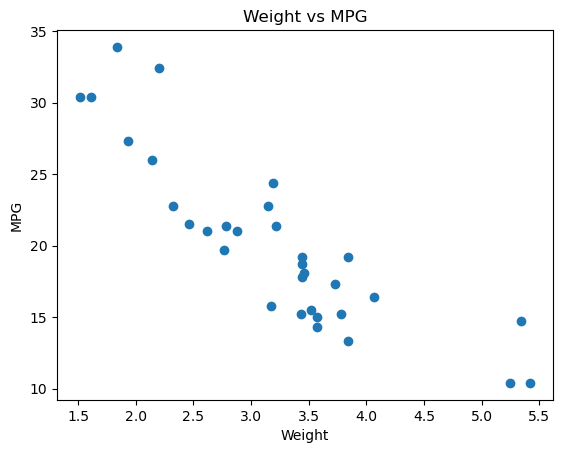

In [69]:
plt.scatter(df['wt'], df['mpg'])
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title('Weight vs MPG')
plt.show()
#Heavier cars have lower MPG

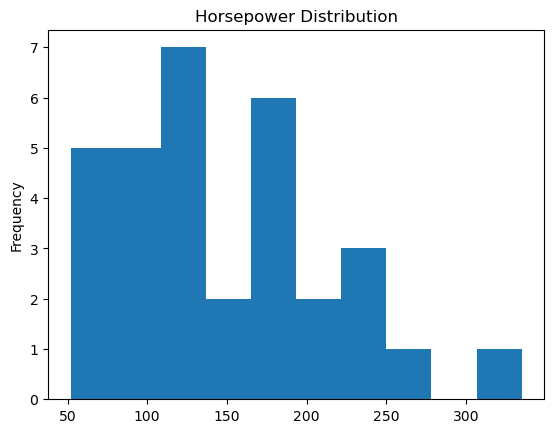

In [66]:
df['hp'].plot(kind='hist', bins=10)
plt.title('Horsepower Distribution')
plt.show()
#Most cars have moderate horsepower

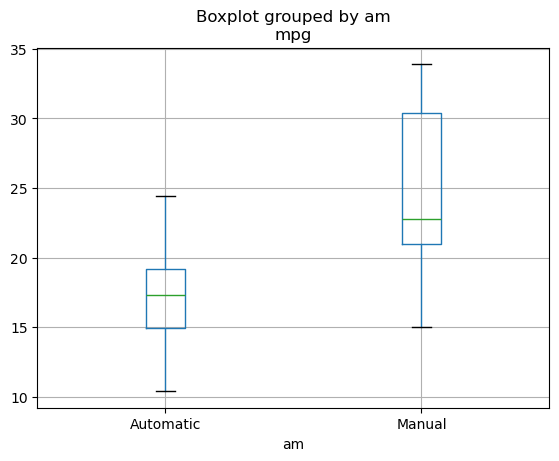

In [68]:
df.boxplot(column='mpg', by='am')
plt.show()
#Manual cars often show higher MPG

In [70]:
#Lighter cars tend to have better fuel efficiency
#Cars with fewer cylinders have higher MPG
#Manual transmission cars often perform better in MPG
#Higher horsepower is generally linked to lower MPG
#Weight has a strong negative correlation with MPG

In [71]:
#This analysis of the mtcars dataset shows that vehicle performance is strongly influenced by weight, engine size, and transmission type. Lighter vehicles and those with fewer cylinders tend to have better fuel efficiency. Manual transmission cars also show slightly better mileage compared to automatic ones. Additionally, higher horsepower is often associated with lower MPG. Overall, the dataset provides clear insights into how design choices affect car performance.